# Semiconductor Yield Intelligence  
## 02 – Exploratory Data Analysis (EDA)

---

### 🎯 Objective

This notebook performs structured exploratory data analysis on the processed wafer dataset.

Goals:
- Understand class distribution
- Visualize wafer spatial patterns
- Analyze defect density
- Identify potential modeling risks

EDA ensures that modeling decisions are data-driven and aligned with semiconductor defect behavior.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import boto3
import os

plt.style.use("seaborn-v0_8")
sns.set_context("talk")

## 🔹 Step 1 – Load Processed Data from S3

All processed datasets are stored in Amazon S3 to ensure reproducibility.

In [5]:
S3_BUCKET = "sagemaker-us-east-1-702452513784"
S3_PREFIX = "wafer-project/processed"

LOCAL_DATA_DIR = "/home/sagemaker-user/MLops-Project-AAI-540/data"
os.makedirs(LOCAL_DATA_DIR, exist_ok=True)

s3 = boto3.client("s3")

files = ["X_train.npy", "y_train.npy"]

for file in files:
    s3.download_file(
        S3_BUCKET,
        f"{S3_PREFIX}/{file}",
        f"{LOCAL_DATA_DIR}/{file}"
    )

X = np.load(f"{LOCAL_DATA_DIR}/X_train.npy")
y = np.load(f"{LOCAL_DATA_DIR}/y_train.npy")

print("Loaded training data:", X.shape)

Loaded training data: (700, 32, 32)


## 🔹 Step 2 – Class Distribution Analysis

Understanding class balance is critical.

In semiconductor analytics:
- Minority defect classes often represent high-risk failures.
- Poor recall on rare classes can cause yield loss.

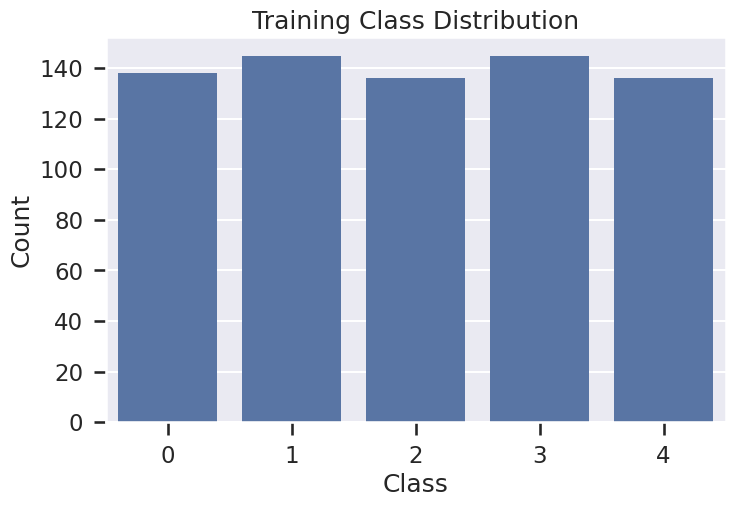

0    138
1    145
2    136
3    145
4    136
Name: count, dtype: int64

In [6]:
class_counts = pd.Series(y).value_counts().sort_index()

plt.figure(figsize=(8,5))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title("Training Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

class_counts

### Insight

Balanced class distribution ensures stable training.

In real wafer datasets:
- Severe imbalance would require class-weighted loss.

## 🔹 Step 3 – Visual Inspection of Wafer Maps

CNN models rely on spatial patterns.

We visually confirm:
- Binary defect representation
- Geometric structure
- Consistency in dimensions

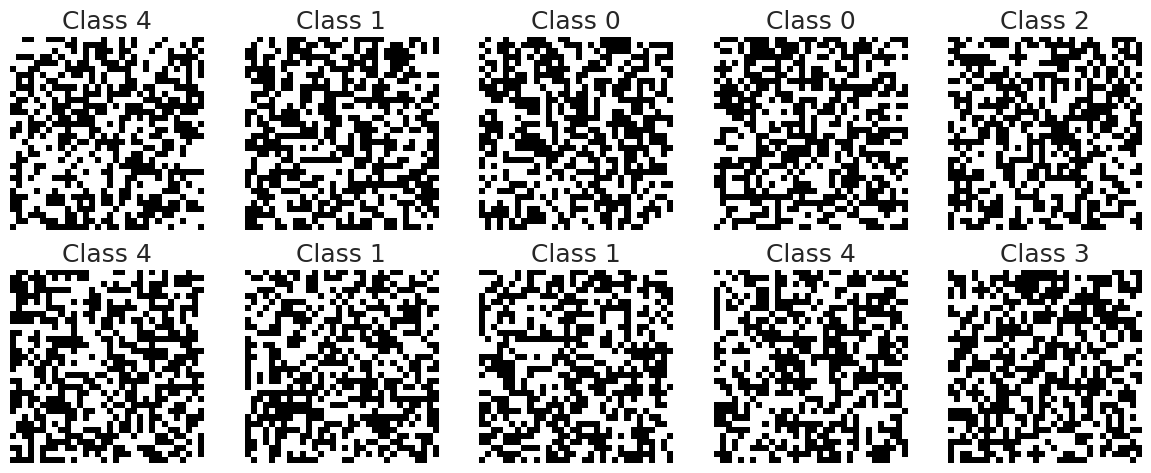

In [7]:
fig, axes = plt.subplots(2,5, figsize=(12,5))

for i in range(10):
    axes[i//5][i%5].imshow(X[i], cmap="gray")
    axes[i//5][i%5].set_title(f"Class {y[i]}")
    axes[i//5][i%5].axis("off")

plt.tight_layout()
plt.show()

## 🔹 Step 4 – Defect Density Analysis

Defect Density = defective pixels / total pixels

This helps understand severity distribution across wafers.

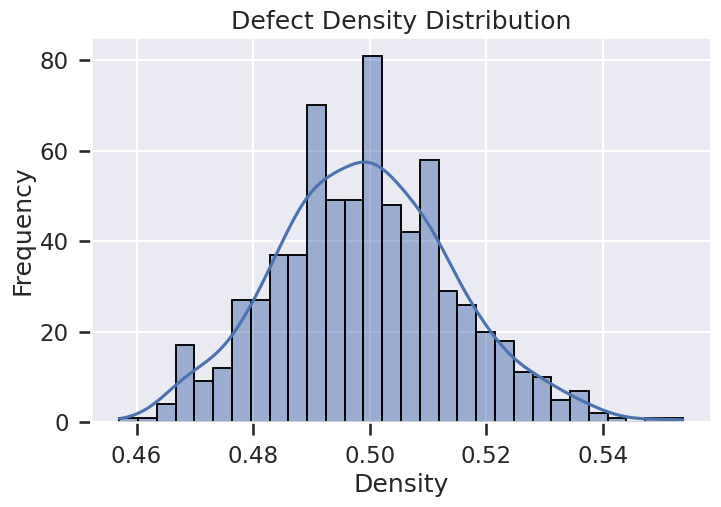

Average Density: 0.4992145647321429


In [8]:
density = X.reshape(X.shape[0], -1).mean(axis=1)

plt.figure(figsize=(8,5))
sns.histplot(density, bins=30, kde=True)
plt.title("Defect Density Distribution")
plt.xlabel("Density")
plt.ylabel("Frequency")
plt.show()

print("Average Density:", density.mean())

# ✅ EDA Summary

Key Findings:
- Class distribution stable
- Spatial patterns clearly visible
- Density varies across wafers

Conclusion:
CNN is appropriate for spatial classification task.